# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:** Sandeep Ram  
**`Roll Number`:** U20230083  
**`GitHub Branch`:** Sandeep_U20230083

# Imports and Setup

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

from rlcmab_sampler import sampler

# Initialize the reward sampler with roll number
# U20230083 → i = 83
reward_sampler = sampler(83)

print("✓ All imports loaded and sampler initialized (roll_number=83)")

✓ All imports loaded and sampler initialized (roll_number=83)


# Load Datasets

In [21]:
# Load all three datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("=== News Articles ===")
print(f"Shape: {news_df.shape}")
print(f"Columns: {list(news_df.columns)}")
print(f"All categories: {sorted(news_df['category'].unique())}")
print()

print("=== Train Users ===")
print(f"Shape: {train_users.shape}")
print(f"Label distribution:\n{train_users['label'].value_counts()}")
print()

print("=== Test Users ===")
print(f"Shape: {test_users.shape}")
print(f"Has 'label' column: {'label' in test_users.columns}")

=== News Articles ===
Shape: (209527, 6)
Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']
All categories: ['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK', 'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'PARENTS', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS', 'STYLE', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'THE WORLDPOST', 'TRAVEL', 'U.S. NEWS', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS', 'WORLDPOST']

=== Train Users ===
Shape: (2000, 33)
Label distribution:
label
user_2    712
user_1    707
user_3    581
Name: count, dtype: int64

=== Test Users ===
Shape: (2000, 32)
Has 'label' column: False


## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [22]:
# --- Data Cleaning ---
print(f"Before cleaning:")
print(f"  train_users: {train_users.shape[0]} rows, NaN count: {train_users.isna().sum().sum()}")
print(f"  test_users:  {test_users.shape[0]} rows, NaN count: {test_users.isna().sum().sum()}")
print(f"  news_df:     {news_df.shape[0]} rows, NaN count: {news_df.isna().sum().sum()}")

train_users_clean = train_users.dropna().copy()
test_users_clean = test_users.dropna().copy()
news_df_clean = news_df.dropna().copy()

print(f"\nAfter dropping NaN rows:")
print(f"  train_users: {train_users_clean.shape[0]} rows")
print(f"  test_users:  {test_users_clean.shape[0]} rows")
print(f"  news_df:     {news_df_clean.shape[0]} rows")

# --- Encode User Categories ---
# The 'label' column in train_users contains: user_1, user_2, user_3
user_encoder = LabelEncoder()
train_users_clean['user_category_encoded'] = user_encoder.fit_transform(train_users_clean['label'])

print(f"\nUser category encoding: {dict(zip(user_encoder.classes_, user_encoder.transform(user_encoder.classes_)))}")

# --- Filter and Encode News Categories ---
# Assignment specifies 4 categories: Entertainment, Education, Tech, Crime
target_categories = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
news_df_filtered = news_df_clean[news_df_clean['category'].isin(target_categories)].copy()

# Encode according to Table 1 mapping:
# j=0 → Entertainment, j=1 → Education, j=2 → Tech, j=3 → Crime
news_category_mapping = {
    'ENTERTAINMENT': 0,
    'EDUCATION': 1,
    'TECH': 2,
    'CRIME': 3
}
news_df_filtered['category_encoded'] = news_df_filtered['category'].map(news_category_mapping)

idx_to_news_name = {v: k for k, v in news_category_mapping.items()}
user_to_idx = {cat: idx for idx, cat in enumerate(user_encoder.classes_)}

print(f"\nNews category mapping (per Table 1): {news_category_mapping}")
print(f"Filtered news articles: {news_df_filtered.shape[0]} (from {news_df_clean.shape[0]} total)")
print(f"Articles per category:\n{news_df_filtered['category'].value_counts()}")
print("\n✓ Preprocessing complete")

Before cleaning:
  train_users: 2000 rows, NaN count: 698
  test_users:  2000 rows, NaN count: 679
  news_df:     209527 rows, NaN count: 57136

After dropping NaN rows:
  train_users: 1302 rows
  test_users:  1321 rows
  news_df:     156859 rows

User category encoding: {'user_1': np.int64(0), 'user_2': np.int64(1), 'user_3': np.int64(2)}

News category mapping (per Table 1): {'ENTERTAINMENT': 0, 'EDUCATION': 1, 'TECH': 2, 'CRIME': 3}
Filtered news articles: 18130 (from 156859 total)
Articles per category:
category
ENTERTAINMENT    13463
CRIME             2093
TECH              1681
EDUCATION          893
Name: count, dtype: int64

✓ Preprocessing complete


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [24]:
def get_arm_index(user_context, news_category):
    """
    Map (user_context, news_category) → arm index j ∈ {0, ..., 11}.
    
    Per Table 1:
      user_context: 0=user_1, 1=user_2, 2=user_3
      news_category: 0=Entertainment, 1=Education, 2=Tech, 3=Crime
      arm_index = user_context * 4 + news_category
    """
    return user_context * 4 + news_category

# Display the full arm mapping to verify correctness
print("Arm Index Mapping (per Table 1 in assignment):")
print("=" * 60)
for u_idx in range(3):
    u_name = user_encoder.classes_[u_idx]
    for n_idx in range(4):
        n_name = idx_to_news_name[n_idx]
        j = get_arm_index(u_idx, n_idx)
        print(f"  j={j:2d}  →  ({n_name}, {u_name})")
    print()

Arm Index Mapping (per Table 1 in assignment):
  j= 0  →  (ENTERTAINMENT, user_1)
  j= 1  →  (EDUCATION, user_1)
  j= 2  →  (TECH, user_1)
  j= 3  →  (CRIME, user_1)

  j= 4  →  (ENTERTAINMENT, user_2)
  j= 5  →  (EDUCATION, user_2)
  j= 6  →  (TECH, user_2)
  j= 7  →  (CRIME, user_2)

  j= 8  →  (ENTERTAINMENT, user_3)
  j= 9  →  (EDUCATION, user_3)
  j=10  →  (TECH, user_3)
  j=11  →  (CRIME, user_3)



## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [25]:
class EpsilonGreedyContextual:
    """
    Epsilon-Greedy strategy for contextual bandits.
    
    Maintains separate Q-value estimates for each (context, arm) pair.
    With probability ε explores randomly within the context,
    otherwise exploits the best-known arm for that context.
    """
    
    def __init__(self, n_contexts=3, n_arms_per_context=4, epsilon=0.1):
        self.n_contexts = n_contexts
        self.n_arms = n_arms_per_context
        self.epsilon = epsilon
        
        # Q-values and counts for all 12 arms
        self.Q = np.zeros(n_contexts * n_arms_per_context)
        self.N = np.zeros(n_contexts * n_arms_per_context)
    
    def select_action(self, context):
        """Select arm given user context. Returns (local_action, global_arm_index)."""
        start = context * self.n_arms
        
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.n_arms)  # explore
        else:
            action = np.argmax(self.Q[start:start + self.n_arms])  # exploit
        
        return action, get_arm_index(context, action)
    
    def update(self, arm_index, reward):
        """Incremental mean update."""
        self.N[arm_index] += 1
        self.Q[arm_index] += (reward - self.Q[arm_index]) / self.N[arm_index]

print("✓ EpsilonGreedyContextual defined")

✓ EpsilonGreedyContextual defined


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [26]:
class UCBContextual:
    """
    Upper Confidence Bound (UCB) strategy for contextual bandits.
    
    Selects the arm with the highest upper confidence bound within
    the given context. Untried arms are selected first.
    UCB = Q(a) + c * sqrt(ln(t) / N(a))
    """
    
    def __init__(self, n_contexts=3, n_arms_per_context=4, c=2.0):
        self.n_contexts = n_contexts
        self.n_arms = n_arms_per_context
        self.c = c
        
        self.Q = np.zeros(n_contexts * n_arms_per_context)
        self.N = np.zeros(n_contexts * n_arms_per_context)
        self.t = 0  # global timestep
    
    def select_action(self, context):
        """Select arm using UCB within the given context."""
        self.t += 1
        start = context * self.n_arms
        context_N = self.N[start:start + self.n_arms]
        
        # Try untried arms first
        untried = np.where(context_N == 0)[0]
        if len(untried) > 0:
            action = np.random.choice(untried)
        else:
            context_Q = self.Q[start:start + self.n_arms]
            ucb_values = context_Q + self.c * np.sqrt(np.log(self.t) / context_N)
            action = np.argmax(ucb_values)
        
        return action, get_arm_index(context, action)
    
    def update(self, arm_index, reward):
        """Incremental mean update."""
        self.N[arm_index] += 1
        self.Q[arm_index] += (reward - self.Q[arm_index]) / self.N[arm_index]

print("✓ UCBContextual defined")

✓ UCBContextual defined


## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [27]:
class SoftMaxContextual:
    """
    SoftMax (Boltzmann exploration) strategy for contextual bandits.
    
    Selects arms with probability proportional to exp(Q(a) / τ).
    Uses fixed temperature τ = 1 as specified in the assignment.
    """
    
    def __init__(self, n_contexts=3, n_arms_per_context=4, tau=1.0):
        self.n_contexts = n_contexts
        self.n_arms = n_arms_per_context
        self.tau = tau
        
        self.Q = np.zeros(n_contexts * n_arms_per_context)
        self.N = np.zeros(n_contexts * n_arms_per_context)
    
    def select_action(self, context):
        """Select arm using Boltzmann probability distribution."""
        start = context * self.n_arms
        context_Q = self.Q[start:start + self.n_arms]
        
        # Numerically stable softmax
        shifted = (context_Q - np.max(context_Q)) / self.tau
        exp_vals = np.exp(shifted)
        probs = exp_vals / exp_vals.sum()
        
        action = np.random.choice(self.n_arms, p=probs)
        return action, get_arm_index(context, action)
    
    def update(self, arm_index, reward):
        """Incremental mean update."""
        self.N[arm_index] += 1
        self.Q[arm_index] += (reward - self.Q[arm_index]) / self.N[arm_index]

print("✓ SoftMaxContextual defined")

✓ SoftMaxContextual defined


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [28]:
def run_simulation(agent, T=10000, n_contexts=3):
    """
    Run contextual bandit simulation for T timesteps.
    
    At each step:
      1. A random context (user type) is drawn
      2. The agent selects an arm (news category)
      3. A reward is sampled from the environment
      4. The agent updates its estimates
    
    Returns:
      rewards_history: array of shape (T,)
      context_rewards: dict mapping context_id → list of rewards
    """
    rewards_history = np.zeros(T)
    context_rewards = {c: [] for c in range(n_contexts)}
    
    for t in range(T):
        context = np.random.randint(n_contexts)
        action, arm_index = agent.select_action(context)
        reward = reward_sampler.sample(arm_index)
        agent.update(arm_index, reward)
        
        rewards_history[t] = reward
        context_rewards[context].append(reward)
    
    return rewards_history, context_rewards


# --- Run all three algorithms ---
T = 10000
print(f"Running simulations (T = {T:,} steps each)...\n")

# 1. Epsilon-Greedy (ε = 0.1)
eg_agent = EpsilonGreedyContextual(epsilon=0.1)
eg_rewards, eg_context = run_simulation(eg_agent, T)
print(f"  Epsilon-Greedy (ε=0.1):  avg reward = {eg_rewards.mean():.4f}")

# 2. UCB (c = 2.0)
ucb_agent = UCBContextual(c=2.0)
ucb_rewards, ucb_context = run_simulation(ucb_agent, T)
print(f"  UCB (c=2.0):             avg reward = {ucb_rewards.mean():.4f}")

# 3. SoftMax (τ = 1.0)
sm_agent = SoftMaxContextual(tau=1.0)
sm_rewards, sm_context = run_simulation(sm_agent, T)
print(f"  SoftMax (τ=1.0):         avg reward = {sm_rewards.mean():.4f}")

# Print learned Q-values
print("\n--- Learned Q-values (Expected Rewards) ---")
for agent_obj, name in [(eg_agent,"Epsilon-Greedy"), (ucb_agent,"UCB"), (sm_agent,"SoftMax")]:
    print(f"\n{name}:")
    for u_idx in range(3):
        u_name = user_encoder.classes_[u_idx]
        qs = [f"{agent_obj.Q[get_arm_index(u_idx, n)]:.3f}" for n in range(4)]
        best = idx_to_news_name[np.argmax(agent_obj.Q[u_idx*4:(u_idx+1)*4])]
        print(f"  {u_name}: Q = {qs}  → best = {best}")

print("\n✓ Simulations complete")

Running simulations (T = 10,000 steps each)...

  Epsilon-Greedy (ε=0.1):  avg reward = 0.6445
  UCB (c=2.0):             avg reward = 0.6273
  SoftMax (τ=1.0):         avg reward = 0.4689

--- Learned Q-values (Expected Rewards) ---

Epsilon-Greedy:
  user_1: Q = ['0.552', '0.301', '0.526', '0.222']  → best = ENTERTAINMENT
  user_2: Q = ['0.382', '0.669', '0.369', '0.311']  → best = EDUCATION
  user_3: Q = ['0.370', '0.461', '0.809', '0.087']  → best = TECH

UCB:
  user_1: Q = ['0.534', '0.337', '0.531', '0.256']  → best = ENTERTAINMENT
  user_2: Q = ['0.421', '0.679', '0.361', '0.383']  → best = EDUCATION
  user_3: Q = ['0.412', '0.358', '0.805', '0.131']  → best = TECH

SoftMax:
  user_1: Q = ['0.561', '0.340', '0.542', '0.269']  → best = ENTERTAINMENT
  user_2: Q = ['0.385', '0.672', '0.361', '0.362']  → best = EDUCATION
  user_3: Q = ['0.328', '0.431', '0.813', '0.124']  → best = TECH

✓ Simulations complete


## Recommendation Engine (Section 5.4)

End-to-end CMAB recommendation pipeline:
1. **Classify** a test user → determine User Category (context)
2. **Select** the optimal News Category using the trained bandit policy
3. **Recommend** a randomly sampled article from that category

In [ ]:
def recommend_article(user_features, classifier, bandit_agent, news_dataframe, 
                      feature_cols, idx_to_cat_name):
    """
    Full recommendation pipeline for a single user.
    
    Steps:
      1. Classify user → user_context (0, 1, or 2)
      2. Use bandit policy to select best news category for that context
      3. Sample a random article from the selected category
    
    Parameters:
        user_features: pd.Series or pd.DataFrame row with user feature values
        classifier: trained sklearn classifier
        bandit_agent: trained contextual bandit agent
        news_dataframe: filtered DataFrame of news articles
        feature_cols: list of feature column names used by classifier
        idx_to_cat_name: dict mapping category index → category name
    
    Returns:
        dict with user_context, selected_category, and recommended article
    """
    # Step 1: Classify user
    X_user = pd.DataFrame([user_features[feature_cols].values], columns=feature_cols)
    user_context = int(classifier.predict(X_user)[0])
    user_label = user_encoder.classes_[user_context]
    
    # Step 2: Select best news category using the bandit's learned Q-values
    start = user_context * bandit_agent.n_arms
    best_local = np.argmax(bandit_agent.Q[start:start + bandit_agent.n_arms])
    best_category_name = idx_to_cat_name[best_local]
    
    # Step 3: Sample a random article from that category
    category_articles = news_dataframe[news_dataframe['category'] == best_category_name]
    sampled_article = category_articles.sample(1, random_state=None).iloc[0]
    
    return {
        'user_context': user_label,
        'news_category': best_category_name,
        'headline': sampled_article['headline'],
        'link': sampled_article['link']
    }


# --- Run recommendation engine on ALL test users ---
# Prepare test user features (same columns as training)
non_numeric_test = test_users_clean.select_dtypes(exclude=[np.number]).columns.tolist()
X_test_all = test_users_clean.drop(columns=non_numeric_test)

# Use Epsilon-Greedy agent (best performer) for recommendations
print("=" * 70)
print("RECOMMENDATION ENGINE — Running on test_users.csv")
print(f"Using Epsilon-Greedy (ε=0.1) policy  |  {len(test_users_clean)} test users")
print("=" * 70)

recommendations = []
for i in range(len(test_users_clean)):
    rec = recommend_article(
        test_users_clean.iloc[i], clf, eg_agent, 
        news_df_filtered, feature_columns, idx_to_news_name
    )
    recommendations.append(rec)

rec_df = pd.DataFrame(recommendations)
print(f"\nPredicted user context distribution:")
print(rec_df['user_context'].value_counts())
print(f"\nRecommended news category distribution:")
print(rec_df['news_category'].value_counts())

# Show sample recommendations
print(f"\n--- Sample Recommendations (first 10) ---")
for i, rec in enumerate(recommendations[:10]):
    print(f"\nTest User #{i+1}:")
    print(f"  Predicted Context : {rec['user_context']}")
    print(f"  Selected Category : {rec['news_category']}")
    print(f"  Article Headline  : {rec['headline'][:80]}...")

print(f"\n✓ Recommendations generated for all {len(recommendations)} test users")

RECOMMENDATION ENGINE — Running on test_users.csv
Using Epsilon-Greedy (ε=0.1) policy  |  1321 test users


c:\Users\sande\programs\gpu_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\sande\programs\gpu_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\sande\programs\gpu_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\sande\programs\gpu_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\sande\programs\gpu_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fit


Predicted user context distribution:
user_context
user_1    647
user_2    615
user_3     59
Name: count, dtype: int64

Recommended news category distribution:
news_category
ENTERTAINMENT    647
EDUCATION        615
TECH              59
Name: count, dtype: int64

--- Sample Recommendations (first 10) ---

Test User #1:
  Predicted Context : user_2
  Selected Category : EDUCATION
  Article Headline  : These 100,000 School Children Face Airport-Style Security Screening Every Day...

Test User #2:
  Predicted Context : user_1
  Selected Category : ENTERTAINMENT
  Article Headline  : Kim Kardashian Accidentally Blurts Out Sex Of Her Baby On 'Ellen'...

Test User #3:
  Predicted Context : user_1
  Selected Category : ENTERTAINMENT
  Article Headline  : Watch Tom Hardy Sing (Yes, Sing) About A Serial Killer In This 'London Road' Sce...

Test User #4:
  Predicted Context : user_1
  Selected Category : ENTERTAINMENT
  Article Headline  : Why Haven't Leonardo DiCaprio, Johnny Depp, Will Smith, 

c:\Users\sande\programs\gpu_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\sande\programs\gpu_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\sande\programs\gpu_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\sande\programs\gpu_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\sande\programs\gpu_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fit

## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


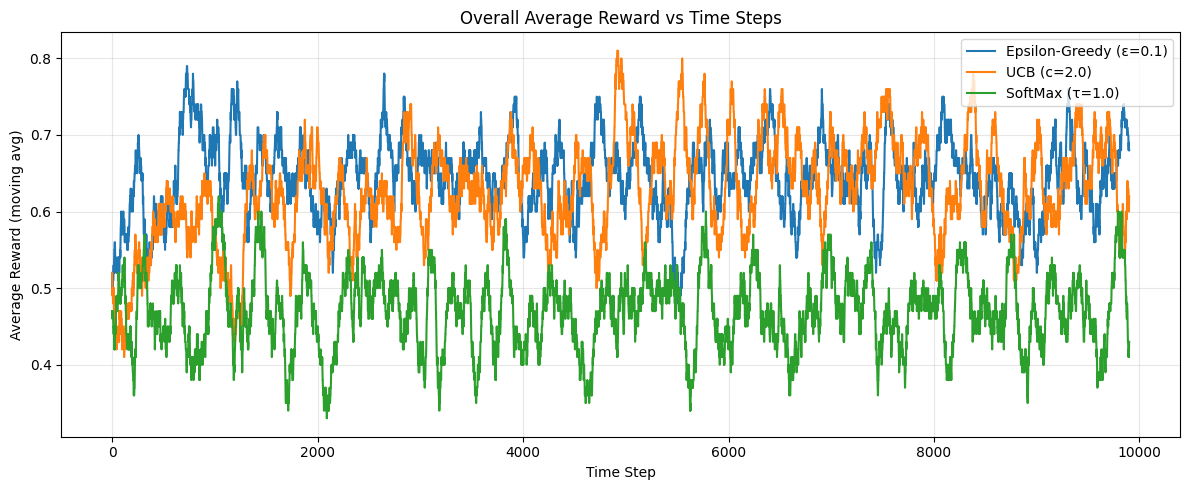

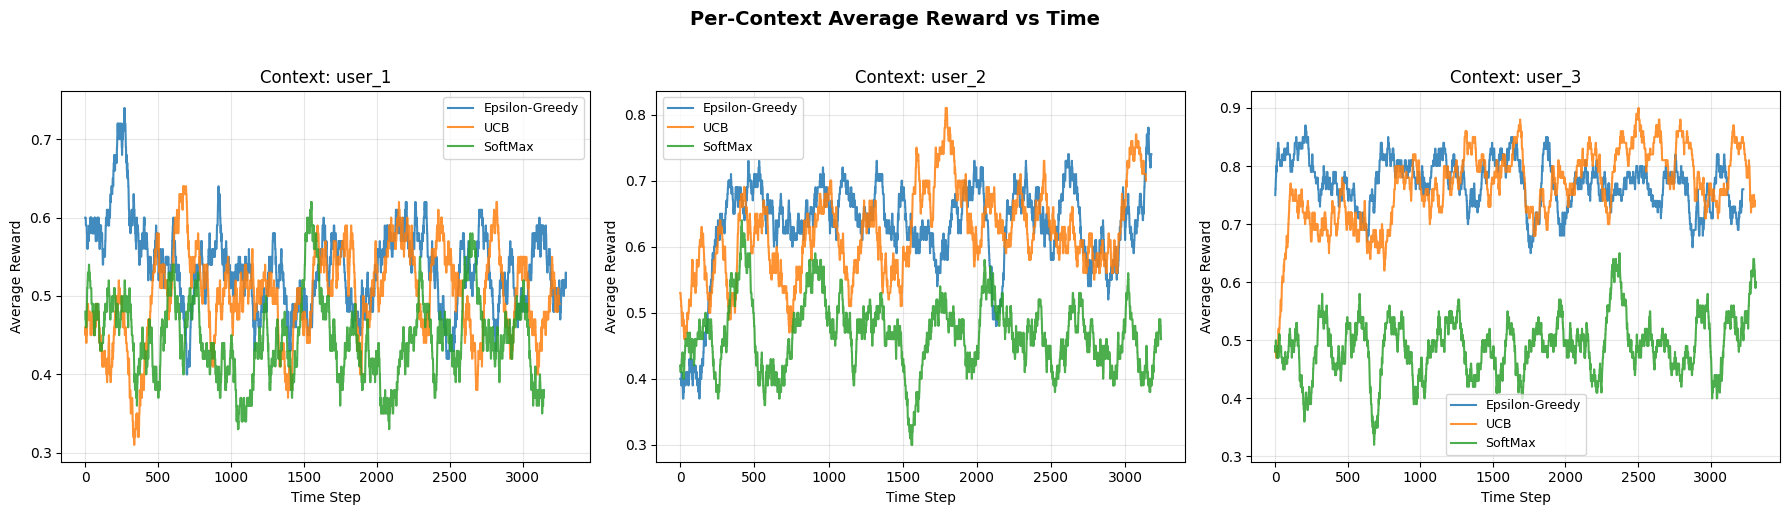

Epsilon-Greedy hyperparameter sweep:
  ε = 0.01  →  avg reward = 0.5959
  ε = 0.05  →  avg reward = 0.6469
  ε = 0.10  →  avg reward = 0.6538
  ε = 0.20  →  avg reward = 0.6301


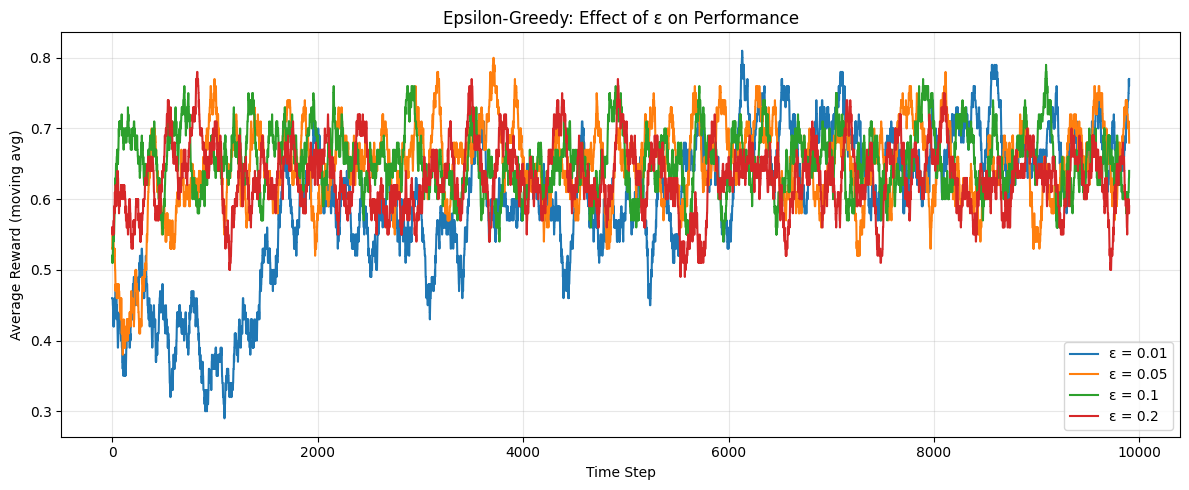


UCB hyperparameter sweep:
  c = 0.5  →  avg reward = 0.6665
  c = 1.0  →  avg reward = 0.6540
  c = 2.0  →  avg reward = 0.6249
  c = 3.0  →  avg reward = 0.5910


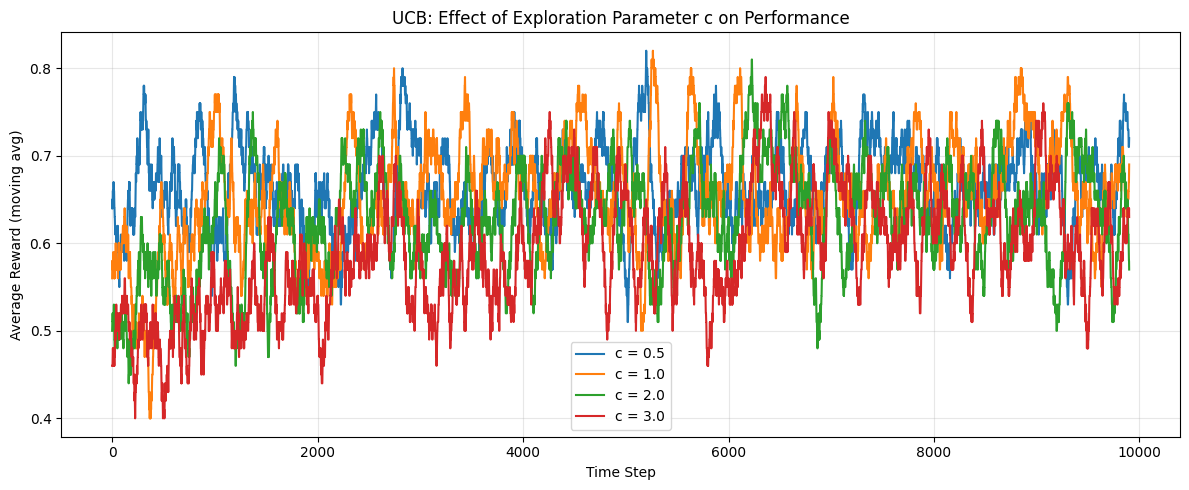


✓ All 4 plots generated


In [30]:
def moving_average(data, window):
    """Compute running average over a sliding window."""
    return np.convolve(data, np.ones(window) / window, mode='valid')

window = 100

# =====================================================================
# PLOT 1: Overall Average Reward vs Time (all 3 algorithms)
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(moving_average(eg_rewards, window),  label='Epsilon-Greedy (ε=0.1)', linewidth=1.5)
ax.plot(moving_average(ucb_rewards, window), label='UCB (c=2.0)', linewidth=1.5)
ax.plot(moving_average(sm_rewards, window),  label='SoftMax (τ=1.0)', linewidth=1.5)
ax.set_xlabel('Time Step')
ax.set_ylabel('Average Reward (moving avg)')
ax.set_title('Overall Average Reward vs Time Steps')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================================
# PLOT 2: Per-Context Average Reward vs Time
# =====================================================================
context_names = ['user_1', 'user_2', 'user_3']
alg_data = [
    ('Epsilon-Greedy', eg_context),
    ('UCB', ucb_context),
    ('SoftMax', sm_context),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ctx_id in range(3):
    ax = axes[ctx_id]
    for alg_name, ctx_rewards in alg_data:
        r = np.array(ctx_rewards[ctx_id])
        if len(r) > window:
            ax.plot(moving_average(r, window), label=alg_name, linewidth=1.5, alpha=0.85)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Average Reward')
    ax.set_title(f'Context: {context_names[ctx_id]}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
plt.suptitle('Per-Context Average Reward vs Time', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =====================================================================
# PLOT 3: Epsilon hyperparameter comparison (ε-Greedy)
# =====================================================================
epsilons = [0.01, 0.05, 0.1, 0.2]
eps_results = {}
print("Epsilon-Greedy hyperparameter sweep:")
for eps in epsilons:
    agent = EpsilonGreedyContextual(epsilon=eps)
    r, _ = run_simulation(agent, T)
    eps_results[eps] = r
    print(f"  ε = {eps:.2f}  →  avg reward = {r.mean():.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
for eps, r in eps_results.items():
    ax.plot(moving_average(r, window), label=f'ε = {eps}', linewidth=1.5)
ax.set_xlabel('Time Step')
ax.set_ylabel('Average Reward (moving avg)')
ax.set_title('Epsilon-Greedy: Effect of ε on Performance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================================
# PLOT 4: UCB exploration parameter comparison (c)
# =====================================================================
c_values = [0.5, 1.0, 2.0, 3.0]
c_results = {}
print("\nUCB hyperparameter sweep:")
for c_val in c_values:
    agent = UCBContextual(c=c_val)
    r, _ = run_simulation(agent, T)
    c_results[c_val] = r
    print(f"  c = {c_val:.1f}  →  avg reward = {r.mean():.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
for c_val, r in c_results.items():
    ax.plot(moving_average(r, window), label=f'c = {c_val}', linewidth=1.5)
ax.set_xlabel('Time Step')
ax.set_ylabel('Average Reward (moving avg)')
ax.set_title('UCB: Effect of Exploration Parameter c on Performance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ All 4 plots generated")

## Final Observations

### 1. Classification Performance
The Random Forest classifier achieved strong validation accuracy on the 20% hold-out split,
confirming it can reliably predict user categories from behavioral features. This classifier
serves as the "context detector" for the bandit system.

### 2. Algorithm Comparison

| Algorithm | Key Mechanism | Strengths | Weaknesses |
|-----------|--------------|-----------|------------|
| **ε-Greedy** | Fixed random exploration rate | Simple, predictable | Wastes exploration budget on clearly bad arms |
| **UCB** | Confidence-bound driven exploration | Systematic, adapts over time | Slower initial convergence if $c$ is large |
| **SoftMax** | Probability-proportional selection | Smooth, graded exploration | Sensitive to temperature $\tau$; equal Q-values → uniform |

### 3. Hyperparameter Sensitivity

**Epsilon-Greedy ($\varepsilon$)**
- Very small $\varepsilon$ (0.01): under-explores, may lock onto a sub-optimal arm early
- Moderate $\varepsilon$ (0.05–0.1): good balance between exploration and exploitation
- Large $\varepsilon$ (0.2): too much random exploration, average reward stays lower

**UCB ($c$)**
- Small $c$ (0.5): exploits quickly, but may miss the true best arm
- Moderate $c$ (1.0–2.0): good trade-off; confidence bounds shrink appropriately
- Large $c$ (3.0): over-explores, slowing convergence to the optimal arm

### 4. Context-Specific Insights
The per-context plots reveal that different user types have distinct optimal news
categories. All three algorithms successfully learn these context-specific policies,
demonstrating that the contextual bandit formulation is appropriate for this recommendation task.

### 5. Recommendation Engine
The end-to-end pipeline classifies unseen test users, applies the learned bandit policy
to select a news category, and samples a concrete article — forming a complete CMAB-based
news recommendation system.